In [98]:
import os
import numpy as np 
import time 

import torch 
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F 
import torch.utils.data as data 

import torchvision.transforms as transforms 
import torchvision.datasets as datasets 

import matplotlib as plt 
from PIL import Image 

In [99]:
ROOT = './data'
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize([32, 32]),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_data = datasets.CIFAR10(
    root=ROOT,
    train=True,
    download=True,
    transform=transform,
)

test_data = datasets.CIFAR10(
    root=ROOT,
    train=False,
    download=True,
    transform=transform
)

In [100]:
VALID_RATIO = 0.9 

n_train_examples = int(len(train_data) * VALID_RATIO)
n_valid_examples = len(train_data) - n_train_examples

generator = torch.Generator().manual_seed(42)
train_data, valid_data = data.random_split(
    train_data, [n_train_examples, n_valid_examples], generator=generator)


In [101]:
print(len(train_data))
print(len(valid_data))
print(len(test_data))

print(test_data.classes)
print()

for i in range(10):
    image, label = train_data[i]
    print(type(image))
    print(image.shape)
    print(label)
    print()

45000
5000
10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
6

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
2

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
8

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
6

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
6

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
9

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
4

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
5

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
4

<class 'torch.Tensor'>
torch.Size([3, 32, 32])
4



In [102]:
BATCH_SIZE = 64

train_dataloader = data.DataLoader(
    train_data, 
    shuffle=True,
    batch_size=BATCH_SIZE
)
valid_dataloader = data.DataLoader(
    valid_data, 
    batch_size=BATCH_SIZE
)

In [103]:
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 5, padding=2, stride=1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        
        self.conv2 = nn.Conv2d(32, 32, 5, padding=2, stride=1)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        
        self.conv3 = nn.Conv2d(32, 64, 5, padding=2, stride=1)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        self.fc1 = nn.Linear(1024, 64)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
        
        
    def forward(self, inputs):
        outputs = self.conv1(inputs)
        outputs = self.relu1(outputs)
        outputs = self.maxpool1(outputs)
        
        outputs = self.conv2(outputs)
        outputs = self.relu2(outputs)
        outputs = self.maxpool2(outputs)
                
        outputs = self.conv3(outputs)
        outputs = self.relu3(outputs)
        outputs = self.maxpool3(outputs)
                
        outputs = self.flatten(outputs)
        
        outputs = self.fc1(outputs)
        outputs = self.relu4(outputs)
        outputs = self.fc2(outputs)
        return outputs

In [104]:
def train(model, optimizer, criterion, dataloader, device):
    model.train()
    total_acc = total_count = 0
    losses = []
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(inputs)
        loss = criterion(predictions, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        total_acc += (predictions.argmax(1) == labels).sum().item()
        total_count += labels.size(0)
    return total_acc / total_count, sum(losses) / len(losses)

In [105]:
def evaluate(model, criterion, dataloader, device):
    model.eval()
    total_acc = total_count = 0
    losses = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            predictions = model(inputs)
            losses.append(criterion(predictions, labels).item())
            total_acc += (predictions.argmax(1) == labels).sum().item()
            total_count += labels.size(0)
    return total_acc / total_count, sum(losses) / len(losses)

In [106]:
num_classes = len(train_data.dataset.classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
custom_model = Net(num_classes)
custom_model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters())

num_epochs = 10
save_model = './model'
os.makedirs(save_model, exist_ok=True)

train_accs, train_losses = [], []
eval_accs, eval_losses = [], []

best_loss_eval = float('inf')

for epoch in range(1, num_epochs+1):
    epoch_start_time = time.time()
    
    train_acc, train_loss = train(custom_model, optimizer, criterion, train_dataloader, device)
    train_accs.append(train_acc)
    train_losses.append(train_loss)
    
    eval_acc, eval_loss = evaluate(custom_model, criterion, valid_dataloader, device)
    eval_accs.append(eval_acc)
    eval_losses.append(eval_loss)
    
    if eval_loss < best_loss_eval:
            best_loss_eval = eval_loss
            torch.save(custom_model.state_dict(), save_model + '/model.pt')
        
        
    print ( "-" * 59)
    print(
    "| End of epoch {:3d} | Time : {:5.2f}s | Train Accuracy {:8.3f} | Train Loss {:8.3f} "
    "| Valid Accuracy {:8.3f} | Valid Loss {:8.3f}".format(
        epoch,
        time.time() - epoch_start_time,
        train_acc,
        train_loss,
        eval_acc,
        eval_loss
        )
    )
    print ( "-" * 59)
    # Load best model
custom_model.load_state_dict(torch.load(save_model + '/model.pt'))
custom_model.eval()

-----------------------------------------------------------
| End of epoch   1 | Time : 25.50s | Train Accuracy    0.473 | Train Loss    1.448 | Valid Accuracy    0.595 | Valid Loss    1.154
-----------------------------------------------------------
-----------------------------------------------------------
| End of epoch   2 | Time : 25.62s | Train Accuracy    0.639 | Train Loss    1.026 | Valid Accuracy    0.666 | Valid Loss    0.938
-----------------------------------------------------------
-----------------------------------------------------------
| End of epoch   3 | Time : 25.94s | Train Accuracy    0.703 | Train Loss    0.850 | Valid Accuracy    0.683 | Valid Loss    0.898
-----------------------------------------------------------
-----------------------------------------------------------
| End of epoch   4 | Time : 26.62s | Train Accuracy    0.743 | Train Loss    0.741 | Valid Accuracy    0.722 | Valid Loss    0.802
--------------------------------------------------------

Net(
  (conv1): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu3): ReLU()
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [107]:
test_dataloader = data.DataLoader(
    test_data, 
    batch_size=BATCH_SIZE
)

test_acc, test_loss = evaluate(custom_model, criterion, test_dataloader, device)

test_acc, test_loss

(0.7353, 0.810709958812993)

In [108]:
all_preds = []
all_labels = []

model = Net(num_classes)
model.load_state_dict(torch.load('./model/model.pt', map_location=device))
model.to(device)
model.eval()

with torch.no_grad():
    for images, labels in test_dataloader:

        # print("Input:", images.shape)

        images = images.to(device)

        outputs = model(images)

        # print("Output:", outputs.shape)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())

        if torch.is_tensor(labels):
            all_labels.extend(labels.cpu().numpy())
        else:
            all_labels.append(labels)

In [109]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.80      0.76      0.78      1000
           1       0.89      0.78      0.83      1000
           2       0.65      0.64      0.64      1000
           3       0.52      0.62      0.56      1000
           4       0.73      0.67      0.70      1000
           5       0.64      0.61      0.62      1000
           6       0.82      0.79      0.81      1000
           7       0.79      0.74      0.76      1000
           8       0.85      0.86      0.86      1000
           9       0.73      0.89      0.80      1000

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



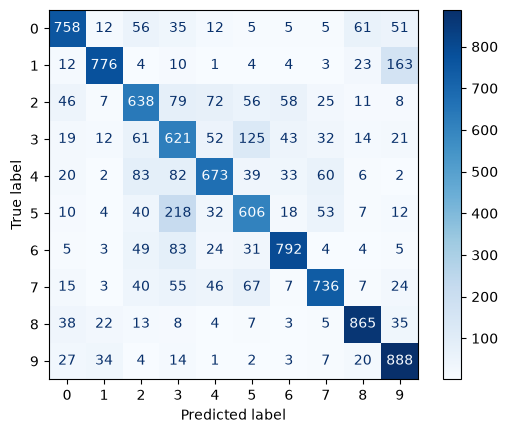

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds)).plot(cmap="Blues")
plt.savefig("confusion.png", dpi=200, bbox_inches="tight")